In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.neural_network import MLPClassifier
from scipy.stats import chi2_contingency

In [ ]:

# Load data
df = pd.read_csv("Loan_default.csv")

In [ ]:
# ===== Step 1: Drop non-feature columns (auto-detect ID-like columns) =====
id_cols = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').nunique() > 100]
print("Dropping ID-like columns:", id_cols.tolist())
df = df.drop(columns=id_cols)

Dropping ID-like columns: ['LoanID']


In [ ]:
# ===== Step 2: Recode categorical variables =====
df['Education'] = df['Education'].replace({'PhD': 'PG', 'Masters': 'PG'})
df['EmploymentType'] = df['EmploymentType'].replace({'Full-time': 'EM', 'Self-employed': 'EM'})
df['LoanPurpose'] = df['LoanPurpose'].replace({'Business': 'BO', 'Other': 'BO'})
df['MaritalStatus'] = df['MaritalStatus'].replace({'Single': 'DS', 'Divorced': 'DS'})

In [ ]:
# ===== Step 3: Scale Income to fix odds ratio ~1 =====
df['Income'] = df['Income'] / 1000

In [ ]:
 #===== Step 4: Drop missing values just in case =====
df.dropna(inplace=True)

In [ ]:
# ===== Step 5: Prepare features/target =====
X = df.drop('Default', axis=1)
y = df['Default']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# ===== Step 6: Train-test split =====
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [ ]:
# ===== Step 7: Standardize numeric features =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ===== Step 8: Logistic Regression =====
logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_scaled, y_train)
logit_probs = logit.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression ROC AUC:", roc_auc_score(y_test, logit_probs))

Logistic Regression ROC AUC: 0.7479214774888086


In [ ]:
# Print top 10 odds ratios
odds_ratios = pd.Series(np.exp(logit.coef_[0]), index=X.columns)
print("\nTop 10 Odds Ratios:")
print(odds_ratios.sort_values(ascending=False).head(10))



Top 10 Odds Ratios:
InterestRate                 1.573928
LoanAmount                   1.340253
EmploymentType_Unemployed    1.149864
NumCreditLines               1.105609
EmploymentType_Part-time     1.064363
DTIRatio                     1.054688
Education_High School        1.028513
LoanTerm                     1.012159
LoanPurpose_BO               1.010272
LoanPurpose_Education        1.005875
dtype: float64


In [ ]:
# Chi-square test: Has Co-Signer vs Default
if 'HasCoSigner' in df.columns:
    contingency = pd.crosstab(df['HasCoSigner'], df['Default'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"\nChi-square p-value (Has Co-Signer vs Default): {p:.4f}")



Chi-square p-value (Has Co-Signer vs Default): 0.0000


In [ ]:
# ===== Step 9: Decision Tree =====
tree = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)
tree.fit(X_train, y_train)
tree_probs = tree.predict_proba(X_test)[:, 1]
print("\nDecision Tree ROC AUC:", roc_auc_score(y_test, tree_probs))



Decision Tree ROC AUC: 0.7156272081942563


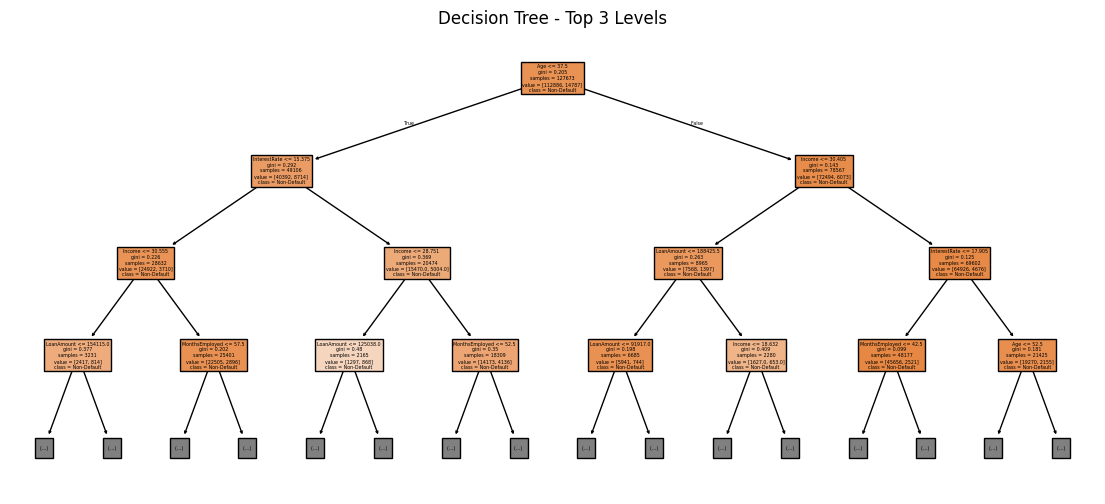

In [ ]:
plt.figure(figsize=(14, 6))
plot_tree(tree, feature_names=X.columns, class_names=['Non-Default', 'Default'], filled=True, max_depth=3)
plt.title("Decision Tree - Top 3 Levels")
plt.show()

In [ ]:
# ===== Step 10: Neural Network =====
nn = MLPClassifier(hidden_layer_sizes=(2,), max_iter=1000, random_state=42)
nn.fit(X_train_scaled, y_train)
nn_probs = nn.predict_proba(X_test_scaled)[:, 1]
print("\nNeural Network ROC AUC:", roc_auc_score(y_test, nn_probs))



Neural Network ROC AUC: 0.755946798348441


In [ ]:
# ===== Step 11: ROC Curve Comparison =====
fpr_logit, tpr_logit, _ = roc_curve(y_test, logit_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)

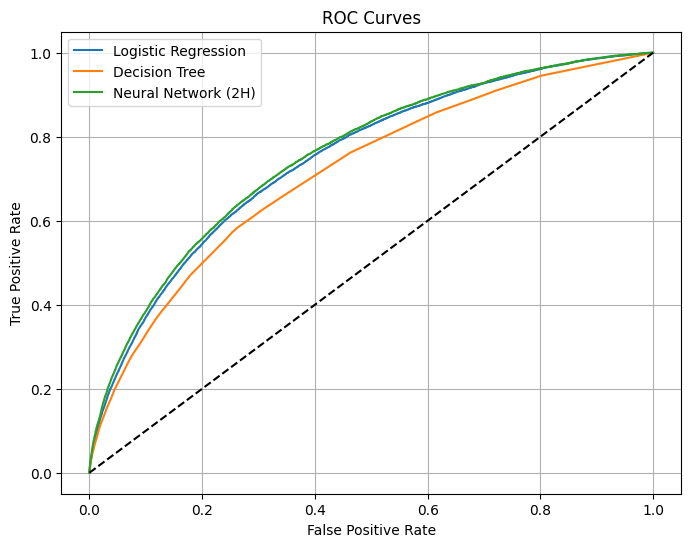

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_logit, tpr_logit, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot(fpr_nn, tpr_nn, label='Neural Network (2H)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.show()

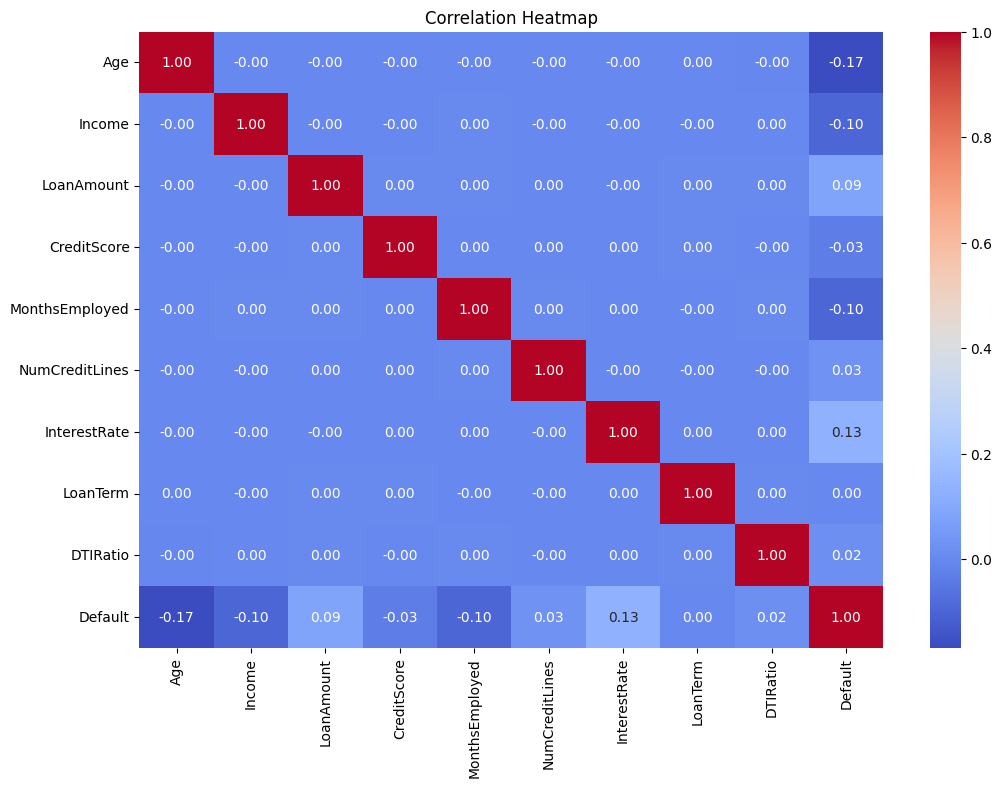

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only include numeric features
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


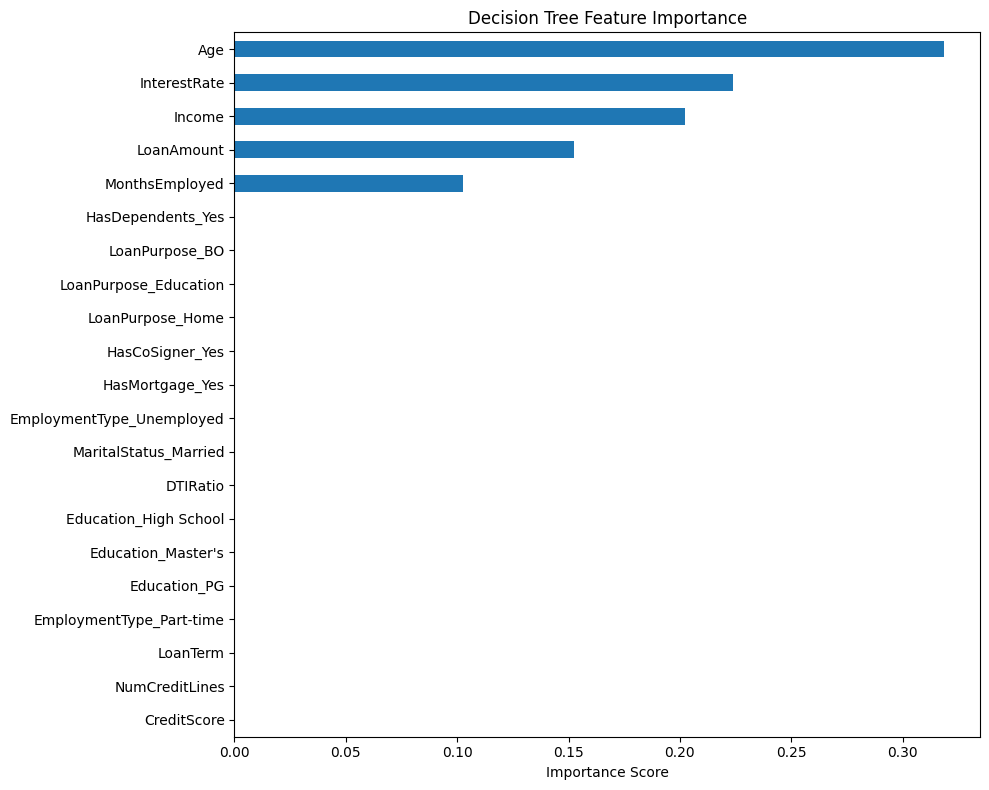

In [ ]:
importances = tree.feature_importances_
feat_importance = pd.Series(importances, index=X.columns)
feat_importance.sort_values(ascending=True).plot(kind='barh', figsize=(10, 8))
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

# Create summary table
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Neural Net (2H)', 'Neural Net (3H)', 'Neural Net (4H)', 'Neural Net (5H)', 'Neural Net (6H)', 'Neural Net (7H)', 'Neural Net (8H)'],
    'ROC AUC': [
        roc_auc_score(y_test, logit_probs),
        roc_auc_score(y_test, tree_probs),
        nn_scores['2 Hidden Nodes'],
        nn_scores['3 Hidden Nodes'],
        nn_scores['4 Hidden Nodes'],
        nn_scores['5 Hidden Nodes'],
        nn_scores['6 Hidden Nodes'],
        nn_scores['7 Hidden Nodes'],
        nn_scores['8 Hidden Nodes']
    ],
    'Misclassification Rate': [
        1 - accuracy_score(y_test, logit.predict(X_test_scaled)),
        1 - accuracy_score(y_test, tree.predict(X_test)),
        1 - accuracy_score(y_test, MLPClassifier(hidden_layer_sizes=(2,), max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        1 - accuracy_score(y_test, MLPClassifier(hidden_layer_sizes=(3,), max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        1 - accuracy_score(y_test, MLPClassifier(hidden_layer_sizes=(4,), max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        1 - accuracy_score(y_test, MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        1 - accuracy_score(y_test, MLPClassifier(hidden_layer_sizes=(6,), max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        1 - accuracy_score(y_test, MLPClassifier(hidden_layer_sizes=(7,), max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        1 - accuracy_score(y_test, MLPClassifier(hidden_layer_sizes=(8,), max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
    ]
})

print("\n📊 Model Performance Summary:")
display(summary.round(4))



📊 Model Performance Summary:


,Model,ROC AUC,Misclassification Rate
0,Logistic Regression,0.7479,0.1153
1,Decision Tree,0.7156,0.1153
2,Neural Net (2H),0.7559,0.1143
3,Neural Net (3H),0.7558,0.1141
4,Neural Net (4H),0.7560,0.1140
5,Neural Net (5H),0.7558,0.1139
6,Neural Net (6H),0.7551,0.1139
7,Neural Net (7H),0.7543,0.1142
8,Neural Net (8H),0.7549,0.1139


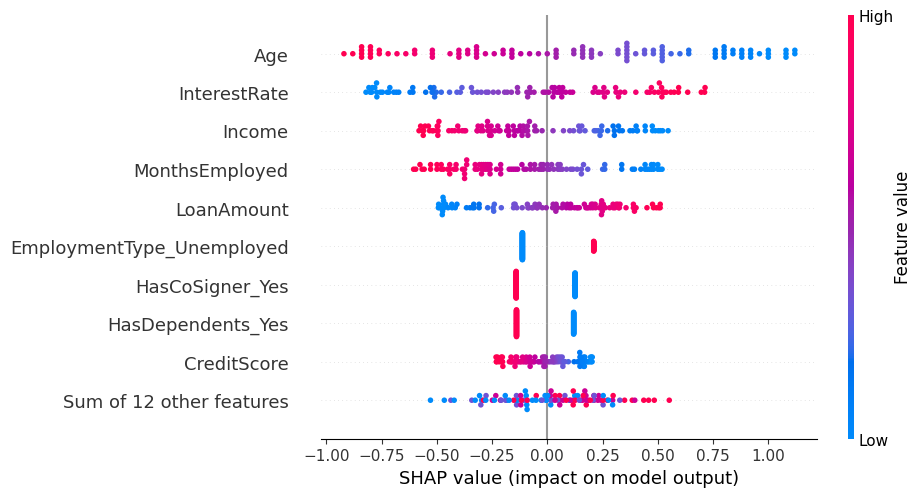

In [ ]:
import shap

# Create SHAP explainer using feature names
explainer = shap.Explainer(logit, X_train_scaled, feature_names=X.columns)

# Calculate SHAP values for a sample (e.g., first 100 test rows)
shap_values = explainer(X_test_scaled[:100])

# Plot beeswarm with readable feature names
shap.plots.beeswarm(shap_values)
